In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df = pd.read_csv('products_asos.csv', on_bad_lines='skip')

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"Data Loaded: {len(df)} rows")
df.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [6]:
df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unknown"
  return "Unknown"

df['brand'] = df['description'].apply(get_brand)
df.head()

,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'product details': 'coats & jackets by new l...,['https://images.asos-media.com/products/new-l...,new
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'product details': 'coats & jackets by new l...,['https://images.asos-media.com/products/new-l...,new
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'product details': 'coats & jackets by new l...,['https://images.asos-media.com/products/new-l...,new
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'product details': 'coats & jackets by new l...,['https://images.asos-media.com/products/new-l...,new
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'product details': 'coats & jackets by strad...,['https://images.asos-media.com/products/strad...,stradivariusjacket


In [9]:
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

df['Brand'] = df['brand'].map(brand_map).fillna(df['brand'])
brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))

Brand
asos              4844
topshopwelcome     711
new                511
river              467
miss               429
Name: count, dtype: int64


In [11]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
      return 0, 0.0

  sizes = size_str.split(',')
  total_sizes = len(sizes)

  out_of_stock_count = size_str.count("Out of stock")

  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate


metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['out_of_stock_count'] = metrics.apply(lambda x: x[0])
df_clean['phantom_rate'] = metrics.apply(lambda x: x[1])

df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['out_of_stock_count']
df_clean['Phantom_Revenue'] = df_clean['price'] * df_clean['phantom_rate']

cols = ['Brand', 'name', 'price', 'out_of_stock_count', 'phantom_rate', 'Lost_Revenue', 'Phantom_Revenue']
df_clean[cols].head()
print(df_clean.sort_values(by='Phantom_Revenue', ascending=False).head(10))

                                                     url  \
3128   https://www.asos.com/the-north-face/the-north-...   
3413   https://www.asos.com/the-north-face/the-north-...   
1107   https://www.asos.com/the-north-face/the-north-...   
21948  https://www.asos.com/topshop/topshop-premium-r...   
3148   https://www.asos.com/the-north-face/the-north-...   
3312   https://www.asos.com/the-north-face/the-north-...   
2941   https://www.asos.com/barbour/barbour-beadnell-...   
2715   https://www.asos.com/asos-design/asos-design-p...   
3093   https://www.asos.com/barbour/barbour-beadnell-...   
15584  https://www.asos.com/asos-edition/asos-edition...   

                                                    name  \
3128   The North Face 1996 Retro Nuptse down puffer j...   
3413   The North Face 1996 Retro Nuptse down jacket i...   
1107      The North Face Freeride 3L ski jacket in white   
21948  Topshop premium real leather collared zip thro...   
3148   The North Face Plus 1996 Retro N

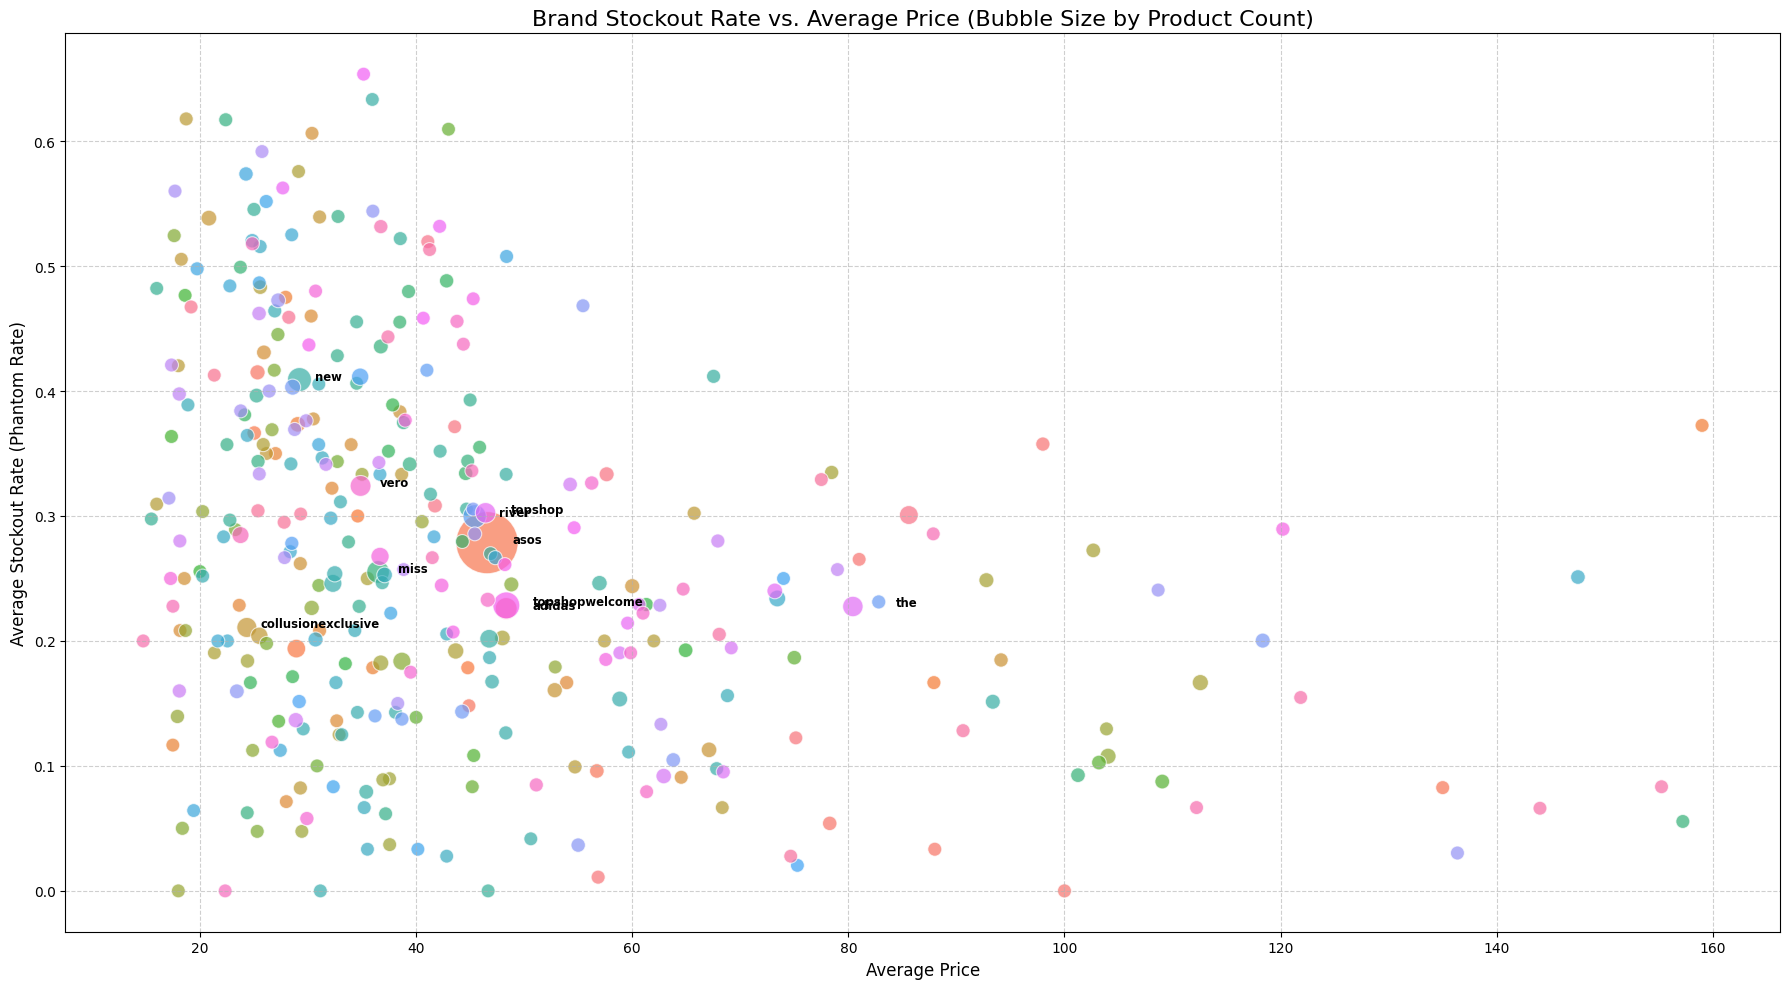

In [17]:
plt.figure(figsize=(18, 10)) # Increased figure size

sns.scatterplot(
    data=scatter_data,
    x='Average_Price',
    y='phantom_rate',
    hue='Brand',
    size='Product_Count',
    sizes=(100, 2000), # Adjusted sizes for better visual distinction
    alpha=0.7,
    legend=False # Hide the legend
)

plt.title('Brand Stockout Rate vs. Average Price (Bubble Size by Product Count)', fontsize=16)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Average Stockout Rate (Phantom Rate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate top brands by Product_Count for better visualization
top_brands_to_annotate = scatter_data.sort_values(by='Product_Count', ascending=False).head(10)
for i, row in top_brands_to_annotate.iterrows():
    plt.text(row['Average_Price'] * 1.05, row['phantom_rate'], row['Brand'],
             horizontalalignment='left', size='small', color='black', weight='semibold')

plt.tight_layout()
plt.show()